In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

In [2]:
# 1. Load the YEARLY CSV Data
file_path = 'data/RWI-GEO-REDX_PUF_v16/RWIGEOREDX_GRIDS_V16_PUF_YEAR_ABS.csv'
print("Loading Yearly RWI CSV...")
df = pd.read_csv(file_path, low_memory=False)

# Keep only valid numeric grids
df = df[df['grid'].str.match(r'^\d+_\d+$', na=False)].copy()

# 2. Extract coordinates and convert to meters for mapping
df[['easting_km', 'northing_km']] = df['grid'].str.split('_', expand=True).astype(float)
df['easting_m'] = df['easting_km'] * 1000
df['northing_m'] = df['northing_km'] * 1000

# 3. Choose the target year column
target_year = '2023'
target_col = f'pindex{target_year}'

df.head()

Loading Yearly RWI CSV...


,grid,housing_type,pindex2008,NOBS2008,pindex2009,NOBS2009,pindex2010,NOBS2010,pindex2011,NOBS2011,...,pindex2023,NOBS2023,pindex2024,NOBS2024,pindex2025,NOBS2025,easting_km,northing_km,easting_m,northing_m
0,4031_3109,HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4031.0,3109.0,4031000.0,3109000.0
1,4031_3110,HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4031.0,3110.0,4031000.0,3110000.0
2,4031_3111,HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4031.0,3111.0,4031000.0,3111000.0
3,4032_3108,HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4032.0,3108.0,4032000.0,3108000.0
4,4032_3109,HK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4032.0,3109.0,4032000.0,3109000.0


Loading map boundaries...


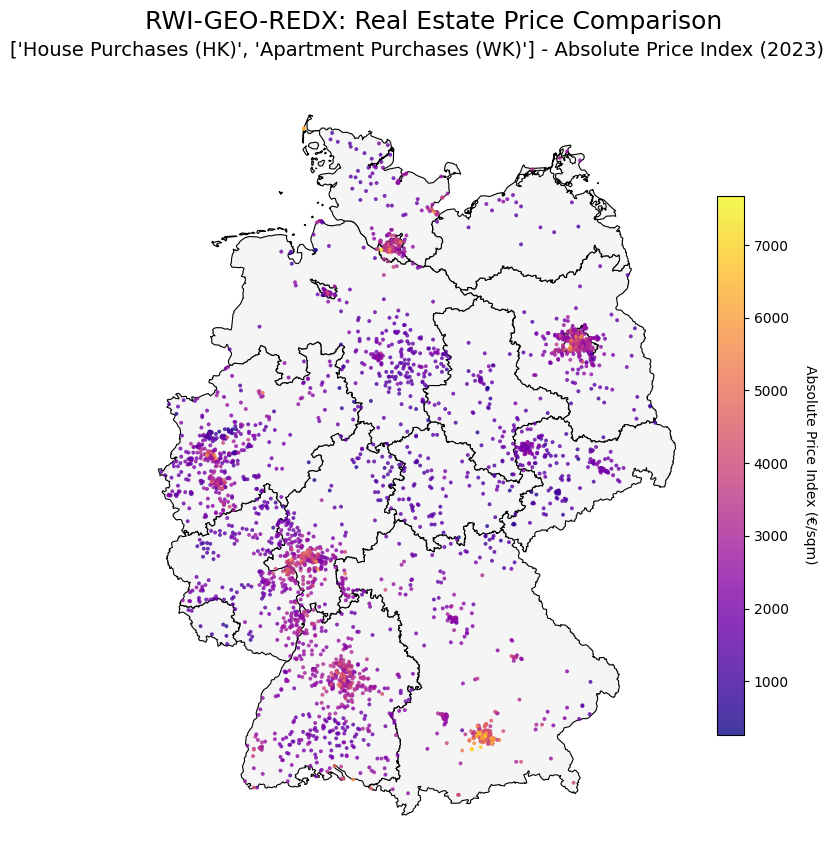

In [3]:
# Load the German Bundesländer borders
print("Loading map boundaries...")
url_geojson = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/3_mittel.geo.json"
germany = gpd.read_file(url_geojson).to_crs(epsg=3035)

# 4. Set up the Side-by-Side Plot
fig, ax = plt.subplots( figsize=(10, 10))
housing_types = ['WK', 'HK']
titles = ['House Purchases (HK)', 'Apartment Purchases (WK)']

# Find the global min and max prices to make the color scales consistent across both maps
# We'll use 5th and 95th percentiles to avoid extreme outliers washing out the colors
combined_data = df[df['housing_type'].isin(housing_types)].dropna(subset=[target_col])
vmin = combined_data[target_col].quantile(0.05)
vmax = combined_data[target_col].quantile(0.95)

# Draw the borders
germany.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=0.8)
    

# 5. Plot each map
for i, h_type in enumerate(housing_types):

    
    # Filter for the specific housing type and drop NA values for this year
    df_map = df[df['housing_type'] == h_type].dropna(subset=[target_col])
    
    # Plot the scatter points
    scatter = ax.scatter(
        x=df_map['easting_m'], 
        y=df_map['northing_m'], 
        c=df_map[target_col], 
        cmap='plasma',            
        s=8, 
        alpha=0.8,
        edgecolors='none',
        #vmin=vmin, # Lock the color scale
       # vmax=vmax  # Lock the color scale
    )
    
    # Formatting
    ax.set_title(f'{titles} - Absolute Price Index ({target_year})', fontsize=14)
    ax.set_axis_off()

# Add a single colorbar for the whole figure
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Absolute Price Index (€/sqm)', rotation=270, labelpad=20)

plt.suptitle('RWI-GEO-REDX: Real Estate Price Comparison', fontsize=18, y=0.95)
plt.show()

In [4]:
# Assuming 'df' exists from previous steps
# and housing_types ['HK', 'WK'] are already defined.
housing_types = ['HK', 'WK']

# Identify pindex columns (ignoring 2024/2025 if empty)
year_cols = [col for col in df.columns if col.startswith('pindex') and col not in ['pindex2024', 'pindex2025']]

# --- 2. RESHAPE DATA (Wide to Long) ---
print("Reshaping data for accumulation...")

# Columns we want to keep uniquely identified
id_vars = ['housing_type', 'easting_m', 'northing_m']

# Perform the melt
df_long = pd.melt(
    df, 
    id_vars=id_vars, 
    value_vars=year_cols,
    var_name='year_raw', # temporary name
    value_name='price_index' # not used for coloring, but useful
)

# Clean up: Extract the 4-digit year and convert to integer
df_long['year'] = df_long['year_raw'].str.extract('(\d{4})').astype(int)

# Optional: Filter by housing type if desired
df_long = df_long[df_long['housing_type'].isin(housing_types)]

# Remove rows where no data exists for that year
df_long_clean = df_long.dropna(subset=['price_index'])

print(f"Data accumulated. Plotting {len(df_long_clean):,} data points...")


Reshaping data for accumulation...
Data accumulated. Plotting 42,956 data points...


In [5]:
df_long_clean.head()
# Define your range
start_year = 2013
end_year = 2013

# Apply the filter
df_filtered = df_long_clean[df_long_clean['year'].between(start_year, end_year)]

print(f"Plotting {len(df_filtered):,} points from {start_year} to {end_year}")

Plotting 3,073 points from 2013 to 2013


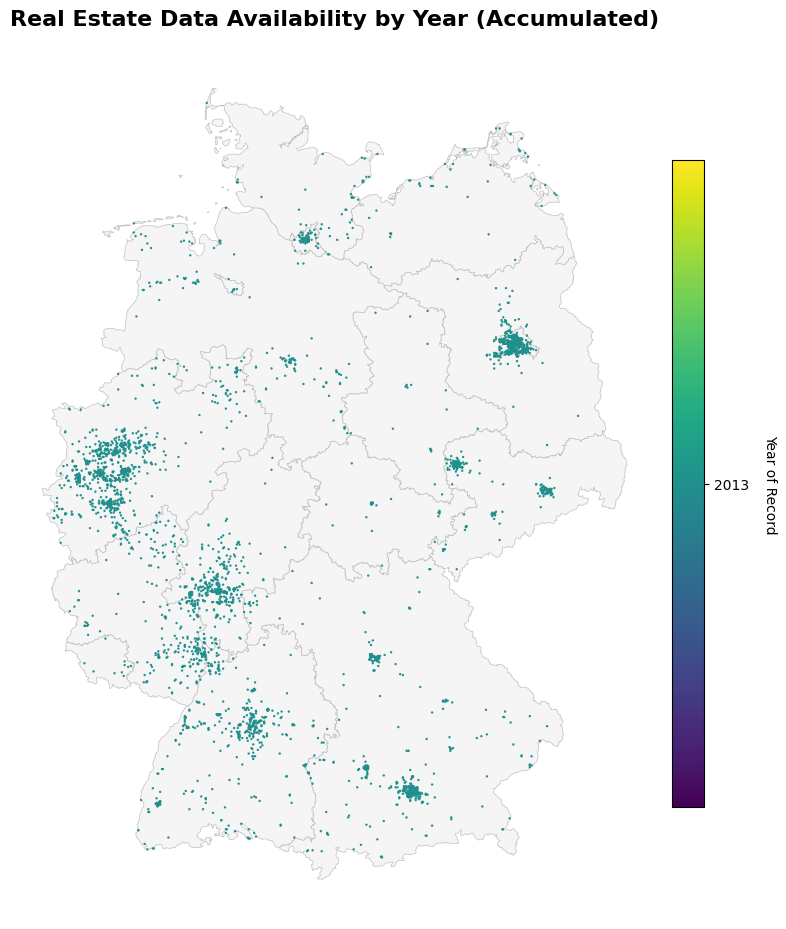

In [6]:
cmap_col = "year"
# --- 3. PLOT ACCUMULATED DATA ---
fig, ax = plt.subplots(figsize=(10, 12))

# Draw borders once (background)
germany.plot(ax=ax, facecolor='whitesmoke', edgecolor='silver', linewidth=0.5, zorder=1)

# Plot ALL points at once
# We use a sequential cmap like 'viridis' or 'plasma' for years
scatter = ax.scatter(
    x=df_filtered['easting_m'], 
    y=df_filtered['northing_m'], 
    c=df_filtered[cmap_col], # Coloring by the newly created integer year column
    cmap='viridis',          # viridis or plasma work well for time sequential
    s=0.5,                   # IMPORTANT: Very small points
    alpha=1.0,               # IMPORTANT: Transparency to manage overlap
    zorder=2
)

# --- 4. FORMATTING ---
ax.set_title('Real Estate Data Availability by Year (Accumulated)', fontsize=16, fontweight='bold')
ax.set_axis_off()

# Colorbar showing years
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Year of Record', rotation=270, labelpad=20)
# Ensure colorbar only shows integer years
if cmap_col == 'year':
    cbar.set_ticks(np.arange(df_filtered['year'].min(), df_filtered['year'].max()+1, 2))

plt.show()

## Generating Data by Landkreis
Joins the RWI_GEO_REDX data on Landkreis level together with geographic data to generate germany map

In [7]:
# 1. Define the path and specific sheet name
# The sheet names in this Excel file usually match the CSV names we discussed

file_path = "data/RWI-GEO-REDX_PUF_v16/RWIGEOREDX_APPURC_V16_PUF_YEAR_ABS.xlsx"
#file_path = "data/RWI-GEO-REDX_PUF_v16/RWIGEOREDX_HOUPURC_V16_PUF_YEAR_ABS.xlsx"
sheet = "Distr_RegionEff_abs_yearly" # Use Munic_ or LMR_ depending on your goal

# 2. Load with skiprows
# RWI files typically have 3-5 rows of title/info at the top of the data sheets
df_distr = pd.read_excel(file_path, sheet_name=sheet, skiprows=0)

# 3. Clean up (sometimes they have an empty first column or row)
df_distr = df_distr.dropna(how='all', axis=0).dropna(how='all', axis=1)

#df_distr.iloc[:5]

In [8]:
def calculate_cagr(df, start_year, end_year, prefix='pindex'):
    n_years = end_year - start_year
    start_col = f'{prefix}{start_year}'
    end_col = f'{prefix}{end_year}'
    
    # CAGR Formel: [(Endwert / Anfangswert) ^ (1/n)] - 1
    # Wir nutzen np.where um Division durch Null oder NaNs abzufangen
    return (df[end_col] / df[start_col])**(1/n_years) - 1

# 5 Jahre (2020-2025)
df_distr['NOBS_yield_5y'] = calculate_cagr(df_distr, 2020, 2025, prefix='NOBS')
# 10 Jahre (2015-2025)
df_distr['NOBS_yield_10y'] = calculate_cagr(df_distr, 2015, 2025, prefix='NOBS')
# Full Dataset (2008-2025)
df_distr['NOBS_yield_full'] = calculate_cagr(df_distr, 2008, 2025, prefix='NOBS')

# Year-to-Year Profit (YoY) für das aktuellste Jahr
df_distr['NOBS_yield_yoy'] = (df_distr['NOBS2025'] / df_distr['NOBS2024']) - 1

# 5 Jahre (2020-2025)
df_distr['yield_5y'] = calculate_cagr(df_distr, 2020, 2025)
# 10 Jahre (2015-2025)
df_distr['yield_10y'] = calculate_cagr(df_distr, 2015, 2025)
# Full Dataset (2008-2025)
df_distr['yield_full'] = calculate_cagr(df_distr, 2008, 2025)

# Year-to-Year Profit (YoY) für das aktuellste Jahr
df_distr['profit_yoy'] = (df_distr['pindex2025'] / df_distr['pindex2024']) - 1

In [9]:
# Wir suchen Ausreißer basierend auf zwei Kriterien:
# 1. NOBS explodiert im Vergleich zum Vorjahr/Nachfolger
# 2. Der Preisindex macht einen unnatürlichen Sprung (> 15% in einem Jahr ist selten)

def detect_real_estate_outliers(df, year):
    # Relativer Sprung NOBS (im Vergleich zum Vorjahr)
    nobs_col = f'NOBS{year}'
    prev_nobs = f'NOBS{year-1}'
    
    # Flag 1: NOBS ist mehr als 5x so groß wie im Vorjahr
    df[f'outlier_nobs_{year}'] = df[nobs_col] > (df[prev_nobs] * 5)
    
    # Flag 2: Preisindex-Sprung (Year-over-Year)
    p_col = f'pindex{year}'
    p_prev = f'pindex{year-1}'
    df[f'pct_change_{year}'] = (df[p_col] / df[p_prev]) - 1
    
    # Alles über 20% Steigerung oder 20% Fall in einem Jahr ist verdächtig
    df[f'outlier_price_{year}'] = df[f'pct_change_{year}'].abs() > 0.20
    
    return df

years = range(2009, 2026)

for year in years:
    detect_real_estate_outliers(df_distr, year)
    bad_rows = df_distr[df_distr[f'outlier_nobs_{year}']]
    print(f"Gefundene Fehler in {year}: {len(bad_rows)}")
    bad_rows[['kid2019',f'NOBS{year}',f'pindex{year}' ]].head()


Gefundene Fehler in 2009: 0
Gefundene Fehler in 2010: 1
Gefundene Fehler in 2011: 0
Gefundene Fehler in 2012: 0
Gefundene Fehler in 2013: 0
Gefundene Fehler in 2014: 0
Gefundene Fehler in 2015: 0
Gefundene Fehler in 2016: 0
Gefundene Fehler in 2017: 0
Gefundene Fehler in 2018: 0
Gefundene Fehler in 2019: 0
Gefundene Fehler in 2020: 0
Gefundene Fehler in 2021: 0
Gefundene Fehler in 2022: 0
Gefundene Fehler in 2023: 0
Gefundene Fehler in 2024: 0
Gefundene Fehler in 2025: 0


In [10]:
landkreise_map = gpd.read_file('data/landkreise_dissolved.geojson')

# 3. Merge
merged = landkreise_map.merge(df_distr, left_on='landkreis_id', right_on='kid2019')


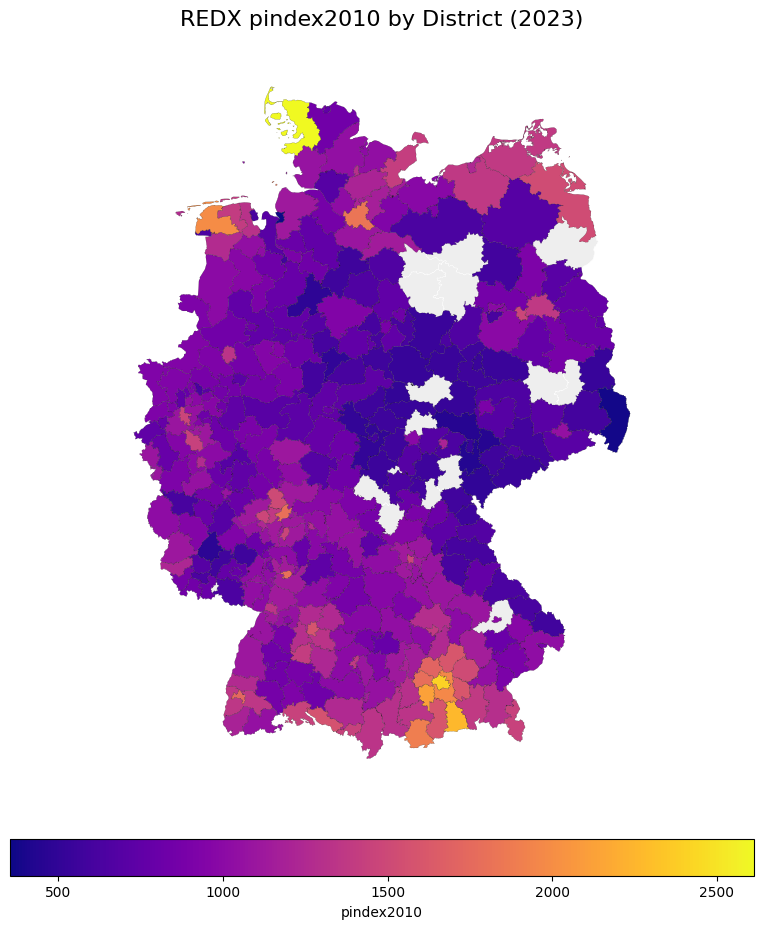

In [11]:

# 5. Plot a specific year (e.g., 2023)
# Ensure the column we want to plot is numeric
col = 'pindex2010'
merged[target_year] = pd.to_numeric(merged[col], errors='coerce')

# 5. Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot districts with NO data in a light gray
landkreise_map.plot(ax=ax, color='#eeeeee', edgecolor='white', linewidth=0.3)

# Plot the merged data
merged.dropna(subset=[target_year]).plot(
    column=target_year, 
    ax=ax, 
    legend=True, 
    cmap='plasma', # 'plasma' or 'YlOrRd' are great for prices
    legend_kwds={
        'label': f"{col}", 
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.8
    },
    edgecolor='black',
    linewidth=0.1
)

ax.set_title(f"REDX {col} by District ({target_year[-4:]})", fontsize=16, pad=20)
ax.set_axis_off()
plt.show()

In [ ]:
df_distr[df_distr['kid2019']=='11000'][[ 'pindex2025', 'pindex2020', 'pindex2015']]

## Processing .geojson

In [ ]:
def remove_holes(geometry):
    if geometry.is_empty:
        return geometry
    if isinstance(geometry, Polygon):
        return Polygon(geometry.exterior)
    elif isinstance(geometry, MultiPolygon):
        # Wir nehmen von jedem Teil-Polygon nur das Äußere
        return MultiPolygon([Polygon(p.exterior) for p in geometry.geoms])
    return geometry

file_districts = "data/gemeinden_simplify20.geojson"
map_districts_process = gpd.read_file(file_districts)

# 1. Den 5-stelligen Landkreis-Code extrahieren
# Wir nehmen die ersten 5 Stellen vom 'RS'
map_districts_process['landkreis_id'] = map_districts['RS'].str[:5]

# 2. Dissolve: Geometrien zusammenfassen
# Wir gruppieren nach 'landkreis_id'. 
# Mit aggfunc='first' behalten wir den ersten Namen (GEN), den er findet.
# Achtung: Das kann bei Landkreisen ungenau sein, da hier oft der Gemeindename steht.
landkreise_map = map_districts_process.dissolve(by='landkreis_id', aggfunc='first')

# 3. Optional: Falls du die richtigen Landkreis-Namen willst
# In deinem Datensatz steht oft in der Spalte 'BEZ' der Typ (z.B. 'Kreis') 
# und in 'GEN' der Name. 
print(landkreise_map[['GEN', 'BEZ']].head())



# Auf die Landkreise anwenden
landkreise_map['geometry'] = landkreise_map.geometry.apply(remove_holes)

# 4. Export als neues GeoJSON für deine Web-Map
landkreise_map.to_file("data/landkreise_dissolved.geojson", driver='GeoJSON')